In [ ]:

!pip install rdkit xgboost lightgbm shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 52.0 MB/s eta 0:00:00


# Machine Learning-Guided Discovery of Broad-Spectrum Antibacterial Compounds

# Data collection and curation from ChEMBL MIC data

In [ ]:
import pandas as pd
import numpy as np
import os, joblib, warnings
warnings.filterwarnings("ignore")

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, classification_report
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
raw = pd.read_csv("raw_mic_data.csv")

raw = raw.dropna(subset=[
    "canonical_smiles",
    "standard_value",
    "standard_units",
    "molecule_chembl_id",
    "target_pref_name"
]).copy()

raw = raw[raw["standard_value"] > 0].copy()

raw = raw[raw["standard_units"].isin([
    "ug.mL-1", "µg.mL-1", "ug/ml", "µg/ml"
])].copy()

raw = raw.drop_duplicates()

target_map = {
    "Staphylococcus aureus": "S. aureus",
    "Escherichia coli": "E. coli",
    "Pseudomonas aeruginosa": "P. aeruginosa"
}

df = raw[raw["target_pref_name"].isin(target_map.keys())].copy()
df["target_clean"] = df["target_pref_name"].replace(target_map)

print(df.shape)
print(df["target_clean"].value_counts())

(189650, 9)
target_clean
S. aureus        105442
E. coli           51512
P. aeruginosa     32696
Name: count, dtype: int64


In [ ]:
agg_df = (
    df.groupby(["molecule_chembl_id", "canonical_smiles", "target_clean"])["standard_value"]
    .agg(
        median_MIC="median",
        mean_MIC="mean",
        n_measurements="count",
        min_MIC="min",
        max_MIC="max"
    )
    .reset_index()
)

print(agg_df.shape)
agg_df.head()

(84903, 8)


,molecule_chembl_id,canonical_smiles,target_clean,median_MIC,mean_MIC,n_measurements,min_MIC,max_MIC
0,CHEMBL100026,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,S. aureus,25.00,25.00,2,10.00,40.00
1,CHEMBL100206,O=C(O)CCSC1=CC(=O)c2ccccc2C1=O,P. aeruginosa,12.50,12.50,1,12.50,12.50
2,CHEMBL100206,O=C(O)CCSC1=CC(=O)c2ccccc2C1=O,S. aureus,12.50,12.50,1,12.50,12.50
3,CHEMBL100214,CCOC(=O)CCCNc1[nH]nc2cccc(OCc3ccc(C(C)(C)C)cc3...,S. aureus,16.00,16.00,2,16.00,16.00
4,CHEMBL100354,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCCNCC3)nc21,E. coli,0.78,0.78,1,0.78,0.78


In [ ]:
ACTIVE_CUTOFF = 16
INACTIVE_CUTOFF = 64

def label_activity(mic):
    if mic <= ACTIVE_CUTOFF:
        return 1
    elif mic > INACTIVE_CUTOFF:
        return 0
    else:
        return np.nan

agg_df["activity"] = agg_df["median_MIC"].apply(label_activity)
agg_df = agg_df.dropna(subset=["activity"]).copy()
agg_df["activity"] = agg_df["activity"].astype(int)

agg_df["activity_label"] = agg_df["activity"].map({
    1: "Active",
    0: "Inactive"
})

print(agg_df["target_clean"].value_counts())
print(pd.crosstab(agg_df["target_clean"], agg_df["activity_label"]))

agg_df.to_csv("cleaned_labeled_MIC_three_pathogens.csv", index=False)

target_clean
S. aureus        33213
E. coli          19698
P. aeruginosa    12264
Name: count, dtype: int64
activity_label  Active  Inactive
target_clean                    
E. coli          14253      5445
P. aeruginosa     8171      4093
S. aureus        27085      6128


# Molecular Descriptor Calculation

Physicochemical descriptors were calculated from the canonical SMILES
representations using the RDKit cheminformatics toolkit.

The following descriptors were generated for each compound:

• Molecular Weight (MW)
• LogP
• Topological Polar Surface Area (TPSA)
• Hydrogen Bond Donors (HBD)
• Hydrogen Bond Acceptors (HBA)
• Rotatable Bonds
• Ring Count
• Heavy Atom Count
• FractionCSP3

Compounds for which valid descriptor values could not be generated
were removed during quality control. The resulting descriptor matrix
was merged with the aggregated MIC dataset and exported for
subsequent machine learning analysis.

In [ ]:
def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # Define the descriptor keys once
        descriptor_keys = [
            "MW", "LogP", "TPSA", "HBD", "HBA",
            "RotBonds", "RingCount", "HeavyAtoms", "FractionCSP3"
        ]
        return {key: np.nan for key in descriptor_keys}

    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotBonds": Descriptors.NumRotatableBonds(mol),
        "RingCount": Descriptors.RingCount(mol),
        "HeavyAtoms": Descriptors.HeavyAtomCount(mol),
        "FractionCSP3": Descriptors.FractionCSP3(mol)
    }

desc_list = []

for smi in agg_df["canonical_smiles"]:
    desc_list.append(calc_descriptors(smi))

desc_df = pd.DataFrame(desc_list)
data = pd.concat([agg_df.reset_index(drop=True), desc_df], axis=1)
data = data.dropna().copy()

data.to_csv("combined_descriptor_dataset_all_pathogens.csv", index=False)

print(data.shape)
data.head()

[05:32:06] Explicit valence for atom # 1 P, 7, is greater than permitted
[05:32:06] Explicit valence for atom # 1 P, 7, is greater than permitted


(65173, 19)


,molecule_chembl_id,canonical_smiles,target_clean,median_MIC,mean_MIC,n_measurements,min_MIC,max_MIC,activity,activity_label,MW,LogP,TPSA,HBD,HBA,RotBonds,RingCount,HeavyAtoms,FractionCSP3
0,CHEMBL100206,O=C(O)CCSC1=CC(=O)c2ccccc2C1=O,P. aeruginosa,12.50,12.50,1,12.50,12.50,1,Active,262.286,2.1574,71.44,1.0,4.0,4.0,2.0,18.0,0.153846
1,CHEMBL100206,O=C(O)CCSC1=CC(=O)c2ccccc2C1=O,S. aureus,12.50,12.50,1,12.50,12.50,1,Active,262.286,2.1574,71.44,1.0,4.0,4.0,2.0,18.0,0.153846
2,CHEMBL100214,CCOC(=O)CCCNc1[nH]nc2cccc(OCc3ccc(C(C)(C)C)cc3...,S. aureus,16.00,16.00,2,16.00,16.00,1,Active,409.530,5.1946,76.24,2.0,5.0,9.0,3.0,30.0,0.416667
3,CHEMBL100354,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCCNCC3)nc21,E. coli,0.78,0.78,1,0.78,0.78,1,Active,334.351,1.0534,87.46,2.0,5.0,3.0,3.0,24.0,0.437500
4,CHEMBL100354,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCCNCC3)nc21,P. aeruginosa,1.56,1.56,1,1.56,1.56,1,Active,334.351,1.0534,87.46,2.0,5.0,3.0,3.0,24.0,0.437500


# Generate Morgan Fingerprints (ECFP-like Representation)

Morgan fingerprints were generated from canonical SMILES using a
radius of 2 and a fingerprint size of 2048 bits. These fingerprints
encode molecular substructures and were used as structural features
for subsequent machine learning model development.

In [ ]:
import pandas as pd
import numpy as np

# Install RDKit to ensure it's available in the environment
!pip install rdkit -q

# RDKit imports
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# =====================================================
# 1. Load descriptor dataset
# =====================================================

df = pd.read_csv("combined_descriptor_dataset_all_pathogens.csv")

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())


# =====================================================
# 2. Define descriptor columns
# =====================================================

descriptor_cols = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotBonds",
    "RingCount",
    "HeavyAtoms",
    "FractionCSP3"
]

print("\nNumber of descriptors:")
print(len(descriptor_cols))


# =====================================================
# 3. Check descriptor missing values
# =====================================================

print("\nMissing values in descriptor columns:")
print(df[descriptor_cols].isna().sum())


# =====================================================
# 4. Descriptor dataset summary
# =====================================================

print("\nDescriptor dataset summary:")
print(df[descriptor_cols].describe().T)


# =====================================================
# 5. Confirm activity/pathogen distribution
# =====================================================

if "target_clean" in df.columns:
    print("\nPathogen distribution:")
    print(df["target_clean"].value_counts())

if "activity_label" in df.columns:
    print("\nActivity label distribution:")
    print(df["activity_label"].value_counts())


# =====================================================
# 6. Identify SMILES column
# =====================================================

possible_smiles_cols = [
    "canonical_smiles",
    "smiles",
    "SMILES",
    "canonical_SMILES"
]

smiles_col = None

for col in possible_smiles_cols:
    if col in df.columns:
        smiles_col = col
        break

print("\nDetected SMILES column:")
print(smiles_col)

if smiles_col is None:
    raise ValueError("No SMILES column found. Please check the column names.")


# =====================================================
# 7. Generate Morgan fingerprints
# =====================================================

def smiles_to_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr


fps = []
valid_indices = []

for idx, smiles in df[smiles_col].items():
    fp = smiles_to_morgan_fp(smiles)

    if fp is not None:
        fps.append(fp)
        valid_indices.append(idx)

X_fp = np.array(fps)

print("\nFingerprint matrix shape:")
print(X_fp.shape)


# =====================================================
# 8. Match descriptors with valid fingerprints
# =====================================================

df_valid = df.loc[valid_indices].reset_index(drop=True)

X_desc = df_valid[descriptor_cols].values

print("\nDescriptor matrix shape after fingerprint validation:")
print(X_desc.shape)


# =====================================================
# 9. Combine descriptors + fingerprints
# =====================================================

X_combined = np.hstack([X_fp, X_desc])

print("\nFinal hybrid feature matrix shape:")
print(X_combined.shape)

print("\nFeature dimension calculation:")
print("Morgan fingerprint bits:", X_fp.shape[1])
print("Descriptor features:", X_desc.shape[1])
print("Total features:", X_combined.shape[1])


# =====================================================
# 10. Number of failed fingerprint generations
# =====================================================

failed_fingerprints = len(df) - len(df_valid)

print("\nFingerprint generation summary:")
print("Original descriptor dataset rows:", len(df))
print("Successfully fingerprinted molecules:", len(df_valid))
print("Failed fingerprint generation:", failed_fingerprints)


# =====================================================
# 11. Save summary results for manuscript
# =====================================================

summary_results = pd.DataFrame({
    "Item": [
        "Descriptor dataset rows",
        "Descriptor dataset columns",
        "Number of molecular descriptors",
        "Successfully fingerprinted molecules",
        "Failed fingerprint generation",
        "Morgan fingerprint bits",
        "Final hybrid feature dimension"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        len(descriptor_cols),
        len(df_valid),
        failed_fingerprints,
        X_fp.shape[1],
        X_combined.shape[1]
    ]
})

summary_results.to_csv(
    "descriptor_fingerprint_generation_summary.csv",
    index=False
)

summary_results.to_excel(
    "descriptor_fingerprint_generation_summary.xlsx",
    index=False
)

print("\nSummary table:")
print(summary_results)

print("\nFiles saved:")
print("descriptor_fingerprint_generation_summary.csv")
print("descriptor_fingerprint_generation_summary.xlsx")

Dataset shape:
(65173, 19)

Columns:
['molecule_chembl_id', 'canonical_smiles', 'target_clean', 'median_MIC', 'mean_MIC', 'n_measurements', 'min_MIC', 'max_MIC', 'activity', 'activity_label', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'RingCount', 'HeavyAtoms', 'FractionCSP3']

Number of descriptors:
9

Missing values in descriptor columns:
MW              0
LogP            0
TPSA            0
HBD             0
HBA             0
RotBonds        0
RingCount       0
HeavyAtoms      0
FractionCSP3    0
dtype: int64

Descriptor dataset summary:
                count        mean         std       min         25%  \
MW            65173.0  544.700252  328.002955  61.04000  372.247000   
LogP          65173.0    3.086910    2.991706 -22.93138    1.856480   
TPSA          65173.0  134.096704  132.992542   0.00000   68.960000   
HBD           65173.0    3.227855    5.023016   0.00000    1.000000   
HBA           65173.0    7.312277    5.458571   0.00000    4.000000   
RotBonds      65173.0 

Streaming output truncated to the last 5000 lines.
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:33:12] DEPRECATION WARNING: please use MorganGenerator
[05:3


Fingerprint matrix shape:
(65173, 2048)

Descriptor matrix shape after fingerprint validation:
(65173, 9)

Final hybrid feature matrix shape:
(65173, 2057)

Feature dimension calculation:
Morgan fingerprint bits: 2048
Descriptor features: 9
Total features: 2057

Fingerprint generation summary:
Original descriptor dataset rows: 65173
Successfully fingerprinted molecules: 65173
Failed fingerprint generation: 0

Summary table:
                                   Item  Value
0               Descriptor dataset rows  65173
1            Descriptor dataset columns     19
2       Number of molecular descriptors      9
3  Successfully fingerprinted molecules  65173
4         Failed fingerprint generation      0
5               Morgan fingerprint bits   2048
6        Final hybrid feature dimension   2057

Files saved:
descriptor_fingerprint_generation_summary.csv
descriptor_fingerprint_generation_summary.xlsx


In [ ]:
def smiles_to_morgan(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Murcko Scaffold Extraction

Bemis–Murcko scaffolds were extracted from all valid molecular
structures using RDKit. Compounds without a valid scaffold were
removed, and the resulting scaffold dataset was exported for
diversity and enrichment analysis.

In [ ]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except:
        return None

data["murcko_scaffold"] = data["canonical_smiles"].apply(get_scaffold)
data = data.dropna(subset=["murcko_scaffold"]).copy()

data.to_csv("descriptor_scaffold_dataset_all_pathogens.csv", index=False)

In [ ]:
import pandas as pd

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("descriptor_scaffold_dataset_all_pathogens.csv")

# Check columns
print(df.columns)

# =====================================================
# Standardize activity labels
# =====================================================

df["activity_label"] = df["activity_label"].replace({
    1: "Active",
    0: "Inactive",
    "active": "Active",
    "inactive": "Inactive"
})

# Remove empty scaffolds
df = df[df["murcko_scaffold"].notna()]
df = df[df["murcko_scaffold"] != ""]

# =====================================================
# Calculate scaffold statistics
# =====================================================

scaffold_stats = (
    df.groupby("murcko_scaffold")
      .agg(
          frequency=("activity_label", "count"),
          active_count=("activity_label",
                        lambda x: (x == "Active").sum()),
          inactive_count=("activity_label",
                          lambda x: (x == "Inactive").sum())
      )
      .reset_index()
)

# =====================================================
# Activity percentages
# =====================================================

scaffold_stats["active_rate"] = (
    scaffold_stats["active_count"] /
    scaffold_stats["frequency"] * 100
)

scaffold_stats["inactive_rate"] = (
    scaffold_stats["inactive_count"] /
    scaffold_stats["frequency"] * 100
)

# =====================================================
# Sort by frequency
# =====================================================

scaffold_stats = scaffold_stats.sort_values(
    "frequency",
    ascending=False
)

# =====================================================
# Top 15 frequent scaffolds
# =====================================================

top15_frequent = scaffold_stats.head(15)

# =====================================================
# Active-enriched scaffolds
# =====================================================

active_enriched = (
    scaffold_stats[scaffold_stats["frequency"] >= 10]
    .sort_values(
        ["active_rate", "frequency"],
        ascending=[False, False]
    )
    .head(15)
)

# =====================================================
# Inactive-enriched scaffolds
# =====================================================

inactive_enriched = (
    scaffold_stats[scaffold_stats["frequency"] >= 10]
    .sort_values(
        ["inactive_rate", "frequency"],
        ascending=[False, False]
    )
    .head(15)
)

# =====================================================
# Pathogen-wise scaffold analysis
# =====================================================

pathogen_tables = {}

if "target_clean" in df.columns:

    for pathogen in df["target_clean"].unique():

        temp = df[df["target_clean"] == pathogen]

        pathogen_stats = (
            temp.groupby("murcko_scaffold")
            .agg(
                frequency=("activity_label", "count"),
                active_count=("activity_label",
                              lambda x: (x == "Active").sum()),
                inactive_count=("activity_label",
                                lambda x: (x == "Inactive").sum())
            )
            .reset_index()
        )

        pathogen_stats["active_rate"] = (
            pathogen_stats["active_count"] /
            pathogen_stats["frequency"] * 100
        )

        pathogen_tables[pathogen] = pathogen_stats.sort_values(
            "frequency",
            ascending=False
        )

# =====================================================
# Export Excel Workbook
# =====================================================

with pd.ExcelWriter(
    "murcko_scaffold_frequency_activity_analysis.xlsx",
    engine="openpyxl"
) as writer:

    scaffold_stats.to_excel(
        writer,
        sheet_name="All_Scaffolds",
        index=False
    )

    top15_frequent.to_excel(
        writer,
        sheet_name="Top15_Frequent",
        index=False
    )

    active_enriched.to_excel(
        writer,
        sheet_name="Top15_Active",
        index=False
    )

    inactive_enriched.to_excel(
        writer,
        sheet_name="Top15_Inactive",
        index=False
    )

    for pathogen, table in pathogen_tables.items():

        safe_name = pathogen.replace(".", "").replace(" ", "_")

        table.to_excel(
            writer,
            sheet_name=safe_name[:31],
            index=False
        )

print("Excel file generated successfully!")

Index(['molecule_chembl_id', 'canonical_smiles', 'target_clean', 'median_MIC',
       'mean_MIC', 'n_measurements', 'min_MIC', 'max_MIC', 'activity',
       'activity_label', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds',
       'RingCount', 'HeavyAtoms', 'FractionCSP3', 'murcko_scaffold'],
      dtype='object')
Excel file generated successfully!


# Active and Inactive Scaffold Comparison

Scaffold distributions were compared between active and inactive
compounds to determine whether antibacterial activity is associated
with specific structural frameworks.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("descriptor_scaffold_dataset_all_pathogens.csv")

# Check columns
print(df.columns)

# Set column names according to your file
scaffold_col = "murcko_scaffold"
label_col = "activity_label"   # Active / Inactive or 1 / 0

# If labels are numeric, convert them
df[label_col] = df[label_col].replace({
    1: "Active",
    0: "Inactive",
    "active": "Active",
    "inactive": "Inactive"
})

# Remove rows without scaffold
df = df[df[scaffold_col].notna()]
df = df[df[scaffold_col] != ""]

# Scaffold summary table
scaffold_stats = (
    df.groupby(scaffold_col)
    .agg(
        frequency=(label_col, "count"),
        active_count=(label_col, lambda x: (x == "Active").sum()),
        inactive_count=(label_col, lambda x: (x == "Inactive").sum())
    )
    .reset_index()
)

scaffold_stats["active_rate"] = (
    scaffold_stats["active_count"] / scaffold_stats["frequency"]
)

scaffold_stats["inactive_rate"] = (
    scaffold_stats["inactive_count"] / scaffold_stats["frequency"]
)

# Top 15 most frequent scaffolds
top15_scaffolds = scaffold_stats.sort_values(
    by="frequency", ascending=False
).head(15)

# Active-enriched scaffolds
active_enriched = scaffold_stats[
    scaffold_stats["frequency"] >= 5
].sort_values(
    by=["active_rate", "frequency"], ascending=[False, False]
).head(15)

# Inactive-enriched scaffolds
inactive_enriched = scaffold_stats[
    scaffold_stats["frequency"] >= 5
].sort_values(
    by=["inactive_rate", "frequency"], ascending=[False, False]
).head(15)

# Save outputs
top15_scaffolds.to_csv("top15_frequent_scaffolds.csv", index=False)
active_enriched.to_csv("top15_active_enriched_scaffolds.csv", index=False)
inactive_enriched.to_csv("top15_inactive_enriched_scaffolds.csv", index=False)

print("Top 15 frequent scaffolds:")
print(top15_scaffolds)

print("\nTop 15 active-enriched scaffolds:")
print(active_enriched)

print("\nTop 15 inactive-enriched scaffolds:")
print(inactive_enriched)

Index(['molecule_chembl_id', 'canonical_smiles', 'target_clean', 'median_MIC',
       'mean_MIC', 'n_measurements', 'min_MIC', 'max_MIC', 'activity',
       'activity_label', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds',
       'RingCount', 'HeavyAtoms', 'FractionCSP3', 'murcko_scaffold'],
      dtype='object')
Top 15 frequent scaffolds:
                                         murcko_scaffold  frequency  \
13853                                           c1ccccc1       1102   
11163                   O=c1ccn(C2CC2)c2cc(N3CCCC3)ccc12        514   
11265                  O=c1ccn(C2CC2)c2cc(N3CCNCC3)ccc12        459   
7779   O=C1COc2ccc(CNC34CCC(CCc5ccnc6cccnc56)(CC3)OC4...        288   
10674                      O=c1cc[nH]c2cc(N3CCNCC3)ccc12        267   
11153                    O=c1ccn(C2CC2)c2cc(N3CCC3)ccc12        234   
6896   O=C1CCCNC(=O)CNC(=O)CNC(=O)CNC(=O)CNC(=O)[C@@H...        228   
1876                          O=C(/C=C/c1ccccc1)c1ccccc1        217   
10726              

# Scaffold Enrichment Analysis

Scaffolds were ranked according to frequency and activity
enrichment. Frequently occurring scaffolds and scaffolds
preferentially associated with active or inactive compounds
were identified for SAR interpretation.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("descriptor_scaffold_dataset_all_pathogens.csv")

# Basic statistics
total_compounds = len(df)
unique_scaffolds = df["murcko_scaffold"].nunique()

print("="*60)
print("MURCKO SCAFFOLD DIVERSITY ANALYSIS")
print("="*60)

print(f"Total compounds: {total_compounds}")
print(f"Unique scaffolds: {unique_scaffolds}")

print(f"Scaffold-to-compound ratio: {unique_scaffolds/total_compounds:.3f}")

# Frequency distribution
scaffold_counts = df["murcko_scaffold"].value_counts()

singletons = (scaffold_counts == 1).sum()
doubletons = (scaffold_counts == 2).sum()

print(f"\nSingleton scaffolds (frequency = 1): {singletons}")
print(f"Doubleton scaffolds (frequency = 2): {doubletons}")

print(f"Singleton percentage: {(singletons/unique_scaffolds)*100:.2f}%")

# Top scaffolds
print("\nTop 20 most frequent scaffolds:")
print(scaffold_counts.head(20))

# Save
scaffold_counts.to_csv(
    "murcko_scaffold_frequency_all.csv",
    header=["frequency"]
)

print("\nMost frequent scaffold:")
print(scaffold_counts.head(1))

MURCKO SCAFFOLD DIVERSITY ANALYSIS
Total compounds: 65173
Unique scaffolds: 14179
Scaffold-to-compound ratio: 0.218

Singleton scaffolds (frequency = 1): 6132
Doubleton scaffolds (frequency = 2): 2829
Singleton percentage: 43.25%

Top 20 most frequent scaffolds:
murcko_scaffold
c1ccccc1                                                                                        1102
O=c1ccn(C2CC2)c2cc(N3CCCC3)ccc12                                                                 514
O=c1ccn(C2CC2)c2cc(N3CCNCC3)ccc12                                                                459
O=C1COc2ccc(CNC34CCC(CCc5ccnc6cccnc56)(CC3)OC4)nc2N1                                             288
O=c1cc[nH]c2cc(N3CCNCC3)ccc12                                                                    267
O=c1ccn(C2CC2)c2cc(N3CCC3)ccc12                                                                  234
O=C1CCCNC(=O)CNC(=O)CNC(=O)CNC(=O)CNC(=O)[C@@H](Cc2ccccc2)NC(=O)CN1                              228
O=C(/C=C/c1ccc

In [ ]:
# Active scaffolds
active_df = df[df["activity_label"] == "Active"]

active_unique_scaffolds = active_df["murcko_scaffold"].nunique()

print("\nACTIVE COMPOUNDS")
print("Compounds:", len(active_df))
print("Unique scaffolds:", active_unique_scaffolds)

# Inactive scaffolds
inactive_df = df[df["activity_label"] == "Inactive"]

inactive_unique_scaffolds = inactive_df["murcko_scaffold"].nunique()

print("\nINACTIVE COMPOUNDS")
print("Compounds:", len(inactive_df))
print("Unique scaffolds:", inactive_unique_scaffolds)


ACTIVE COMPOUNDS
Compounds: 48616
Unique scaffolds: 11905

INACTIVE COMPOUNDS
Compounds: 15351
Unique scaffolds: 3725


In [ ]:
# Scaffold frequency statistics

print("\nScaffold frequency statistics")
print(scaffold_counts.describe())


Scaffold frequency statistics
count    14179.000000
mean         4.511390
std         14.736207
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       1102.000000
Name: count, dtype: float64



# Dataset Distribution and Train/Test Split Summary

# This section summarizes the final pathogen-specific datasets
# after descriptor and fingerprint generation. For each target
# pathogen (S. aureus, E. coli, and P. aeruginosa), the code:
#
# 1. Removes compounds with invalid Morgan fingerprints.
# 2. Calculates the total number of compounds.
# 3. Determines the number and percentage of active compounds.
# 4. Determines the number and percentage of inactive compounds.
# 5. Calculates the corresponding 80:20 train-test split sizes.

In [ ]:
# After loading your main dataframe (df)
print("=== Dataset Size per Pathogen ===\n")

for pathogen in ["S. aureus", "E. coli", "P. aeruginosa"]:
    pathogen_df = df[df["target_clean"] == pathogen].copy()

    # After SMILES to fingerprint filtering (same as in your function)
    fps = pathogen_df["canonical_smiles"].apply(smiles_to_morgan)
    valid_idx = fps.notna()
    pathogen_df = pathogen_df[valid_idx]

    total = len(pathogen_df)
    active = (pathogen_df["activity"] == 1).sum()
    inactive = (pathogen_df["activity"] == 0).sum()

    print(f"{pathogen}:")
    print(f"   Total compounds     : {total}")
    print(f"   Active              : {active} ({active/total*100:.1f}%)")
    print(f"   Inactive            : {inactive} ({inactive/total*100:.1f}%)")

    # Show 80:20 split sizes
    train_size = int(total * 0.8)
    test_size = total - train_size
    print(f"   Train set (80%)     : {train_size}")
    print(f"   Test set (20%)      : {test_size}")
    print("-" * 40)

=== Dataset Size per Pathogen ===



Streaming output truncated to the last 5000 lines.
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:37:59] DEPRECATION WARNING: please use MorganGenerator
[05:3

S. aureus:
   Total compounds     : 32691
   Active              : 26662 (81.6%)
   Inactive            : 6029 (18.4%)
   Train set (80%)     : 26152
   Test set (20%)      : 6539
----------------------------------------


Streaming output truncated to the last 5000 lines.
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:38:12] DEPRECATION WARNING: please use MorganGenerator
[05:3

E. coli:
   Total compounds     : 19268
   Active              : 13949 (72.4%)
   Inactive            : 5319 (27.6%)
   Train set (80%)     : 15414
   Test set (20%)      : 3854
----------------------------------------


Streaming output truncated to the last 5000 lines.
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:38:20] DEPRECATION WARNING: please use MorganGenerator
[05:3

P. aeruginosa:
   Total compounds     : 12008
   Active              : 8005 (66.7%)
   Inactive            : 4003 (33.3%)
   Train set (80%)     : 9606
   Test set (20%)      : 2402
----------------------------------------


[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerator
[05:38:23] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

print("=== 5-Fold Cross-Validation ===\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['matthews_corrcoef', 'roc_auc', 'f1']

for pathogen in ["S. aureus", "E. coli", "P. aeruginosa"]:

    # Filter pathogen
    pathogen_df = df[df["target_clean"] == pathogen].copy()

    # Generate fingerprints
    fps = pathogen_df["canonical_smiles"].apply(smiles_to_morgan)
    valid_idx = fps.notna()
    pathogen_df = pathogen_df[valid_idx]
    fps = fps[valid_idx]

    # Build feature matrix (same as your existing pipeline)
    X = np.array(fps.tolist())
    y = pathogen_df["activity"].values

    # Run CV
    model = ExtraTreesClassifier(class_weight='balanced', random_state=42)
    results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    print(f"{pathogen}:")
    print(f"  MCC     : {np.mean(results['test_matthews_corrcoef']):.3f} "
          f"± {np.std(results['test_matthews_corrcoef']):.3f}")
    print(f"  ROC-AUC : {np.mean(results['test_roc_auc']):.3f} "
          f"± {np.std(results['test_roc_auc']):.3f}")
    print(f"  F1      : {np.mean(results['test_f1']):.3f} "
          f"± {np.std(results['test_f1']):.3f}")
    print("-" * 40)

=== 5-Fold Cross-Validation ===



Streaming output truncated to the last 5000 lines.
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:42:40] DEPRECATION WARNING: please use MorganGenerator
[05:4

S. aureus:
  MCC     : 0.760 ± 0.013
  ROC-AUC : 0.958 ± 0.005
  F1      : 0.958 ± 0.002
----------------------------------------


Streaming output truncated to the last 5000 lines.
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:46:42] DEPRECATION WARNING: please use MorganGenerator
[05:4

E. coli:
  MCC     : 0.791 ± 0.008
  ROC-AUC : 0.957 ± 0.000
  F1      : 0.943 ± 0.003
----------------------------------------


Streaming output truncated to the last 5000 lines.
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:49:07] DEPRECATION WARNING: please use MorganGenerator
[05:4

P. aeruginosa:
  MCC     : 0.796 ± 0.014
  ROC-AUC : 0.959 ± 0.003
  F1      : 0.932 ± 0.005
----------------------------------------


In [ ]:
# Save training SMILES for Tanimoto novelty filter
training_smiles = agg_df[['canonical_smiles']].drop_duplicates().dropna()
training_smiles.to_csv("training_smiles.csv", index=False)
print(f"Saved {len(training_smiles)} unique training SMILES")

Saved 41028 unique training SMILES



# Machine Learning Model Development and Evaluation
# For each pathogen-specific dataset, molecular fingerprints
# (Morgan fingerprints; radius=2, nBits=2048) were combined
# with nine physicochemical descriptors to generate a hybrid
# feature matrix.
# Model performance was evaluated on the independent test set
# using Accuracy, Precision, Recall, F1-score, ROC-AUC,
# PR-AUC, and Matthews Correlation Coefficient (MCC).
# ============================================================

In [ ]:
def train_pathogen_models(df, pathogen_name):
    pathogen_df = df[df["target_clean"] == pathogen_name].copy()

    fps = pathogen_df["canonical_smiles"].apply(smiles_to_morgan)
    valid_idx = fps.notna()

    pathogen_df = pathogen_df[valid_idx].copy()
    fps = fps[valid_idx]

    X_fp = np.vstack(fps.values)

    descriptor_cols = [
        "MW", "LogP", "TPSA", "HBD", "HBA",
        "RotBonds", "RingCount", "HeavyAtoms", "FractionCSP3"
    ]

    X_desc = pathogen_df[descriptor_cols].values
    X = np.hstack([X_fp, X_desc])
    y = pathogen_df["activity"].values

    X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
        X,
        y,
        pathogen_df.index,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    xgb = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    et = ExtraTreesClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    lgbm = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    models = {
        "RandomForest": rf,
        "XGBoost": xgb,
        "ExtraTrees": et,
        "LightGBM": lgbm
    }

    results = []
    predictions = pd.DataFrame({"true_activity": y_test})

    for name, model in models.items():
        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "Pathogen": pathogen_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            "F1": f1_score(y_test, pred),
            "ROC_AUC": roc_auc_score(y_test, prob),
            "PR_AUC": average_precision_score(y_test, prob),
            "MCC": matthews_corrcoef(y_test, pred)
        })

        predictions[f"{name}_prediction"] = pred
        predictions[f"{name}_probability"] = prob

        safe_name = pathogen_name.replace(".", "").replace(" ", "_")
        joblib.dump(model, f"{safe_name}_{name}_model.pkl")

    ensemble_prob = (
        predictions["RandomForest_probability"] +
        predictions["XGBoost_probability"] +
        predictions["ExtraTrees_probability"] +
        predictions["LightGBM_probability"]
    ) / 4

    ensemble_pred = (ensemble_prob >= 0.5).astype(int)

    results.append({
        "Pathogen": pathogen_name,
        "Model": "SoftVoting_Ensemble",
        "Accuracy": accuracy_score(y_test, ensemble_pred),
        "Precision": precision_score(y_test, ensemble_pred),
        "Recall": recall_score(y_test, ensemble_pred),
        "F1": f1_score(y_test, ensemble_pred),
        "ROC_AUC": roc_auc_score(y_test, ensemble_prob),
        "PR_AUC": average_precision_score(y_test, ensemble_prob),
        "MCC": matthews_corrcoef(y_test, ensemble_pred)
    })

    predictions["Ensemble_prediction"] = ensemble_pred
    predictions["Ensemble_probability"] = ensemble_prob

    safe_name = pathogen_name.replace(".", "").replace(" ", "_")
    pd.DataFrame(results).to_csv(f"{safe_name}_model_results.csv", index=False)
    predictions.to_csv(f"{safe_name}_test_predictions.csv", index=False)

    return {
        "pathogen": pathogen_name,
        "data": pathogen_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "models": models,
        "results": pd.DataFrame(results),
        "predictions": predictions,
        "feature_names": [f"FP_{i}" for i in range(2048)] + descriptor_cols
    }

In [ ]:
all_outputs = {}

for pathogen in ["S. aureus", "E. coli", "P. aeruginosa"]:
    print(f"\nTraining models for {pathogen}")
    output = train_pathogen_models(data, pathogen)
    all_outputs[pathogen] = output
    display(output["results"])


Training models for S. aureus


Streaming output truncated to the last 5000 lines.
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:30:53] DEPRECATION WARNING: please use MorganGenerator
[06:3

[LightGBM] [Info] Number of positive: 21667, number of negative: 4902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.982255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5497
[LightGBM] [Info] Number of data points in the train set: 26569, number of used features: 2057
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,Pathogen,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,S. aureus,RandomForest,0.924131,0.934394,0.975448,0.954480,0.958020,0.988926,0.733568
1,S. aureus,XGBoost,0.904260,0.911517,0.977478,0.943346,0.935859,0.982715,0.653587
2,S. aureus,ExtraTrees,0.924733,0.940039,0.969540,0.954562,0.954136,0.986384,0.738747
3,S. aureus,LightGBM,0.895228,0.963297,0.906037,0.933790,0.946372,0.985689,0.691441
4,S. aureus,SoftVoting_Ensemble,0.923227,0.942790,0.964371,0.953459,0.956533,0.988711,0.736081



Training models for E. coli


...

,Pathogen,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,E. coli,RandomForest,0.913706,0.927186,0.955805,0.941278,0.960469,0.982666,0.780020
1,E. coli,XGBoost,0.883503,0.893939,0.951947,0.922032,0.932697,0.968948,0.697999
2,E. coli,ExtraTrees,0.915228,0.930846,0.953700,0.942134,0.957657,0.978330,0.784583
3,E. coli,LightGBM,0.888071,0.941716,0.901087,0.920954,0.944421,0.973791,0.731700
4,E. coli,SoftVoting_Ensemble,0.905330,0.924025,0.947036,0.935389,0.957425,0.981498,0.759263



Training models for P. aeruginosa


Streaming output truncated to the last 5000 lines.
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:41:47] DEPRECATION WARNING: please use MorganGenerator
[06:4

[LightGBM] [Info] Number of positive: 6537, number of negative: 3274
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.215854 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5290
[LightGBM] [Info] Number of data points in the train set: 9811, number of used features: 1978
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,Pathogen,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,P. aeruginosa,RandomForest,0.909091,0.925769,0.938800,0.932239,0.963339,0.979053,0.794358
1,P. aeruginosa,XGBoost,0.884223,0.893816,0.937576,0.915173,0.943531,0.968593,0.735295
2,P. aeruginosa,ExtraTrees,0.911945,0.931265,0.936965,0.934106,0.960841,0.977309,0.801466
3,P. aeruginosa,LightGBM,0.890746,0.927409,0.906977,0.917079,0.952479,0.973553,0.757445
4,P. aeruginosa,SoftVoting_Ensemble,0.905014,0.922752,0.935741,0.929201,0.962103,0.979747,0.785127


In [ ]:
all_results = pd.concat(
    [all_outputs[p]["results"] for p in all_outputs],
    axis=0
)

all_results.to_csv("all_pathogen_model_performance.csv", index=False)
all_results

,Pathogen,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,S. aureus,RandomForest,0.924131,0.934394,0.975448,0.954480,0.958020,0.988926,0.733568
1,S. aureus,XGBoost,0.904260,0.911517,0.977478,0.943346,0.935859,0.982715,0.653587
2,S. aureus,ExtraTrees,0.924733,0.940039,0.969540,0.954562,0.954136,0.986384,0.738747
3,S. aureus,LightGBM,0.895228,0.963297,0.906037,0.933790,0.946372,0.985689,0.691441
4,S. aureus,SoftVoting_Ensemble,0.923227,0.942790,0.964371,0.953459,0.956533,0.988711,0.736081
0,E. coli,RandomForest,0.913706,0.927186,0.955805,0.941278,0.960469,0.982666,0.780020
1,E. coli,XGBoost,0.883503,0.893939,0.951947,0.922032,0.932697,0.968948,0.697999
2,E. coli,ExtraTrees,0.915228,0.930846,0.953700,0.942134,0.957657,0.978330,0.784583
3,E. coli,LightGBM,0.888071,0.941716,0.901087,0.920954,0.944421,0.973791,0.731700
4,E. coli,SoftVoting_Ensemble,0.905330,0.924025,0.947036,0.935389,0.957425,0.981498,0.759263


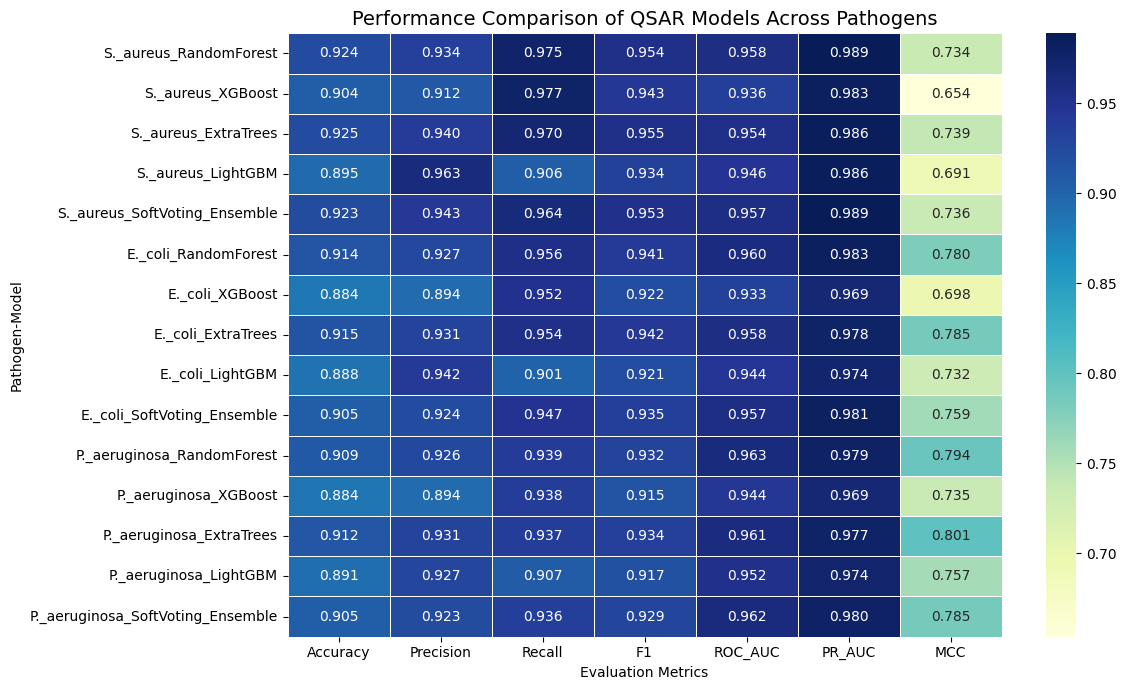

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# If all_results is already in memory, use it directly.
# Otherwise:
# all_results = pd.read_csv("all_pathogen_model_performance.csv")

heatmap_df = all_results.copy()

heatmap_df["Pathogen_Model"] = (
    heatmap_df["Pathogen"].str.replace(" ", "_") + "_" + heatmap_df["Model"]
)

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "MCC"]

heatmap_data = heatmap_df.set_index("Pathogen_Model")[metrics]

plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Performance Comparison of QSAR Models Across Pathogens", fontsize=14)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Pathogen-Model")
plt.tight_layout()

plt.savefig("model_comparison_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
!pip install shap -q

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

In [ ]:
!pip install shap -q

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# ==========================================================
# SHAP INTERPRETABILITY ANALYSIS
# ==========================================================

Using existing 'data' variable: (65173, 20)

SHAP Analysis: S. aureus
Model        : Descriptor-only Extra Trees (9 features)
Justification: Morgan fingerprint bits lack direct
               physicochemical interpretability.
               Descriptors (HBD, LogP, TPSA, MW etc.)
               carry clear mechanistic meaning.
               Full hybrid model (2057 features) used
               separately for virtual screening.

Compounds : 33212
Active    : 27084
Inactive  : 6128
Features  : 9 physicochemical descriptors

Descriptor-only model performance:
  Accuracy : 0.883
  F1-score : 0.931
  ROC-AUC  : 0.901
  MCC      : 0.569

  Note: Lower than hybrid model — expected.
  Descriptor-only model used for SHAP only,
  not for virtual screening.
              precision    recall  f1-score   support

    Inactive       0.79      0.50      0.61      1226
      Active       0.90      0.97      0.93      5417

    accuracy                           0.88      6643
   macro avg       0.84  

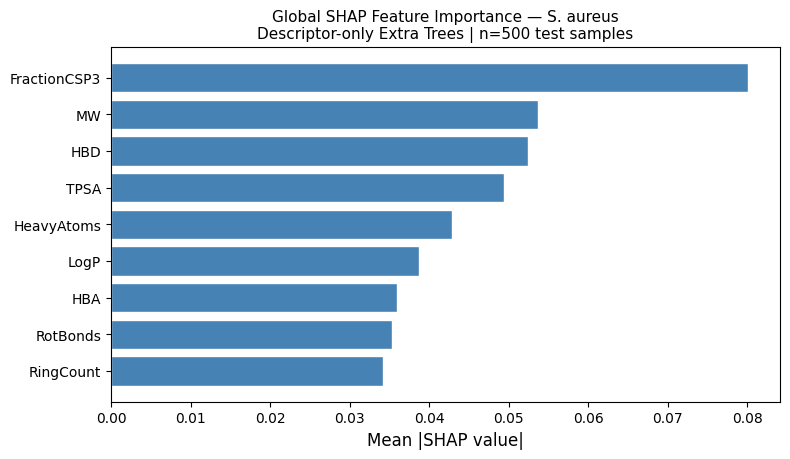

Saved: SHAP_global_S_aureus.png


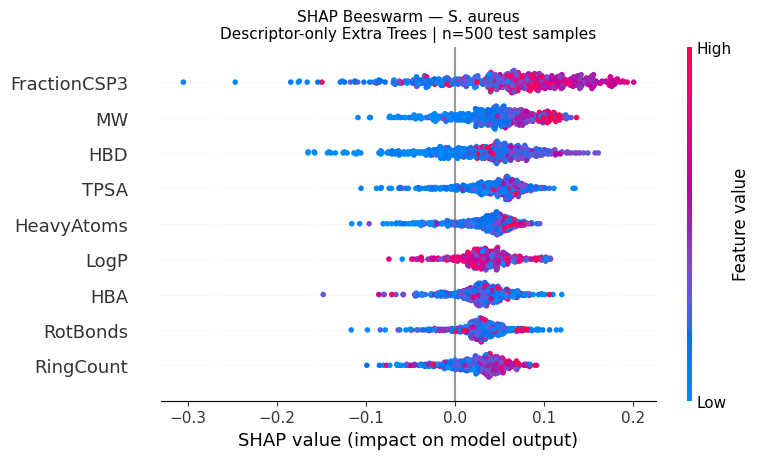

Saved: SHAP_beeswarm_S_aureus.png

SHAP Analysis: E. coli
Model        : Descriptor-only Extra Trees (9 features)
Justification: Morgan fingerprint bits lack direct
               physicochemical interpretability.
               Descriptors (HBD, LogP, TPSA, MW etc.)
               carry clear mechanistic meaning.
               Full hybrid model (2057 features) used
               separately for virtual screening.

Compounds : 19697
Active    : 14252
Inactive  : 5445
Features  : 9 physicochemical descriptors

Descriptor-only model performance:
  Accuracy : 0.849
  F1-score : 0.899
  ROC-AUC  : 0.902
  MCC      : 0.604

  Note: Lower than hybrid model — expected.
  Descriptor-only model used for SHAP only,
  not for virtual screening.
              precision    recall  f1-score   support

    Inactive       0.78      0.63      0.70      1089
      Active       0.87      0.93      0.90      2851

    accuracy                           0.85      3940
   macro avg       0.82      0.78    

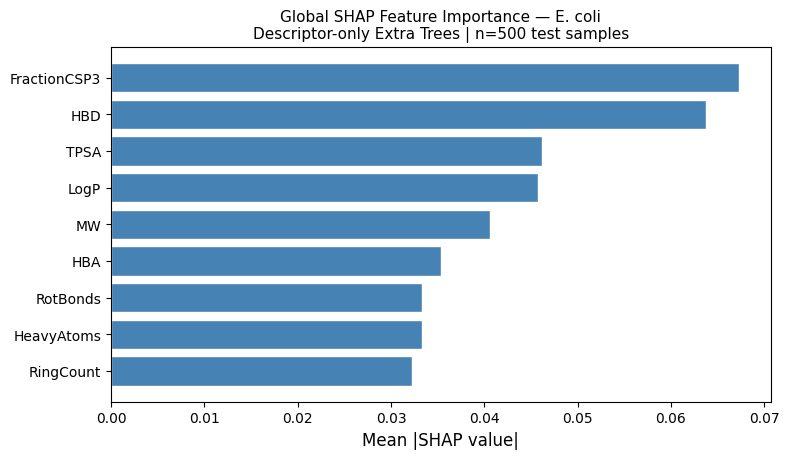

Saved: SHAP_global_E_coli.png


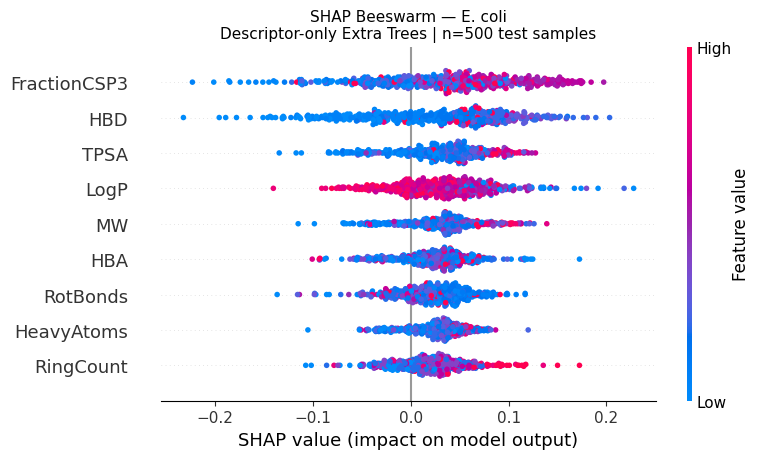

Saved: SHAP_beeswarm_E_coli.png

SHAP Analysis: P. aeruginosa
Model        : Descriptor-only Extra Trees (9 features)
Justification: Morgan fingerprint bits lack direct
               physicochemical interpretability.
               Descriptors (HBD, LogP, TPSA, MW etc.)
               carry clear mechanistic meaning.
               Full hybrid model (2057 features) used
               separately for virtual screening.

Compounds : 12264
Active    : 8171
Inactive  : 4093
Features  : 9 physicochemical descriptors

Descriptor-only model performance:
  Accuracy : 0.839
  F1-score : 0.882
  ROC-AUC  : 0.914
  MCC      : 0.630

  Note: Lower than hybrid model — expected.
  Descriptor-only model used for SHAP only,
  not for virtual screening.
              precision    recall  f1-score   support

    Inactive       0.79      0.71      0.75       819
      Active       0.86      0.91      0.88      1634

    accuracy                           0.84      2453
   macro avg       0.82      0.81 

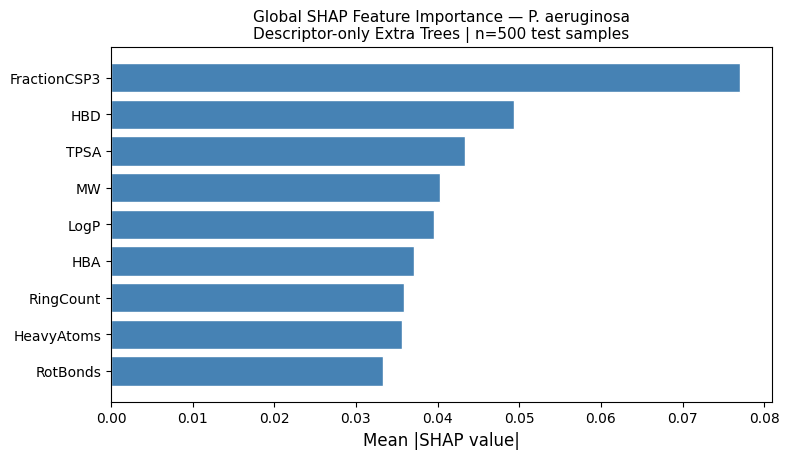

Saved: SHAP_global_P_aeruginosa.png


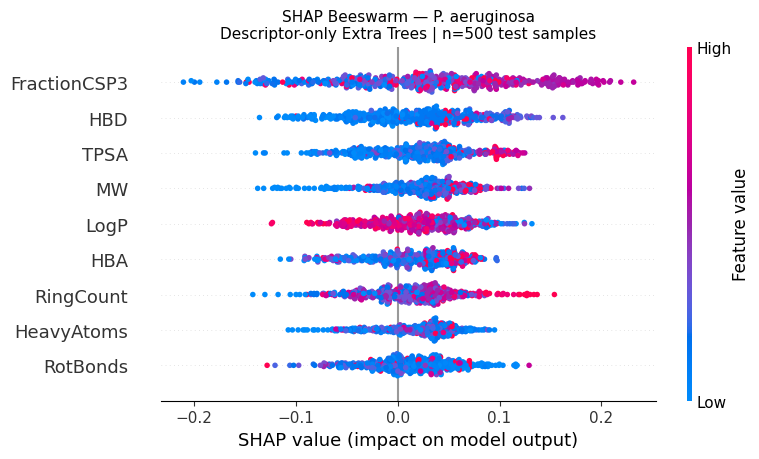

Saved: SHAP_beeswarm_P_aeruginosa.png

SHAP ANALYSIS COMPLETE
6 figures saved (300 DPI):
  SHAP_global_S_aureus.png
  SHAP_beeswarm_S_aureus.png
  SHAP_global_E_coli.png
  SHAP_beeswarm_E_coli.png
  SHAP_global_P_aeruginosa.png
  SHAP_beeswarm_P_aeruginosa.png

MANUSCRIPT ALIGNMENT:
  Section 2.8 : Descriptor-only model, 9 features, seed=42
  Section 3.8 : Feature importance from this output
  Screening   : Hybrid model (2057 features) — separate


In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, matthews_corrcoef,
                             classification_report)

# ─────────────────────────────────────────
# STEP 1 — Load data
# ─────────────────────────────────────────
try:
    _ = data.shape
    print(f"Using existing 'data' variable: {data.shape}")
except NameError:
    print("Loading from CSV...")
    data = pd.read_csv("combined_descriptor_dataset_all_pathogens.csv")
    print(f"Loaded: {data.shape}")

DESCRIPTOR_COLS = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA',
                   'RotBonds', 'RingCount', 'HeavyAtoms', 'FractionCSP3']

# ─────────────────────────────────────────
# STEP 2 — SHAP per pathogen
# ─────────────────────────────────────────
for pathogen in ["S. aureus", "E. coli", "P. aeruginosa"]:

    print(f"\n{'='*60}")
    print(f"SHAP Analysis: {pathogen}")
    print(f"Model        : Descriptor-only Extra Trees (9 features)")
    print(f"Justification: Morgan fingerprint bits lack direct")
    print(f"               physicochemical interpretability.")
    print(f"               Descriptors (HBD, LogP, TPSA, MW etc.)")
    print(f"               carry clear mechanistic meaning.")
    print(f"               Full hybrid model (2057 features) used")
    print(f"               separately for virtual screening.")
    print(f"{'='*60}")

    # Filter pathogen
    pathogen_df = data[data["target_clean"] == pathogen].copy()
    pathogen_df = pathogen_df.dropna(subset=DESCRIPTOR_COLS + ['activity'])

    X_desc = pathogen_df[DESCRIPTOR_COLS].values
    y      = pathogen_df["activity"].values

    print(f"\nCompounds : {len(pathogen_df)}")
    print(f"Active    : {(y == 1).sum()}")
    print(f"Inactive  : {(y == 0).sum()}")
    print(f"Features  : {len(DESCRIPTOR_COLS)} physicochemical descriptors")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_desc, y, test_size=0.2, stratify=y, random_state=42
    )

    # Train descriptor-only ET model
    model = ExtraTreesClassifier(class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    # Performance
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\nDescriptor-only model performance:")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"  F1-score : {f1_score(y_test, y_pred):.3f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}")
    print(f"  MCC      : {matthews_corrcoef(y_test, y_pred):.3f}")
    print(f"\n  Note: Lower than hybrid model — expected.")
    print(f"  Descriptor-only model used for SHAP only,")
    print(f"  not for virtual screening.")
    print(classification_report(y_test, y_pred,
                                target_names=['Inactive', 'Active']))

    # SHAP — 500 samples
    np.random.seed(42)
    n_shap = min(500, len(X_test))
    idx    = np.random.choice(len(X_test), n_shap, replace=False)
    X_shap = X_test[idx]

    print(f"Computing SHAP on {n_shap} samples (seed=42)...")
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_shap)

    # ── FIX: handle all possible SHAP output shapes ──
    print(f"SHAP output type : {type(shap_vals)}")
    if isinstance(shap_vals, list):
        print(f"SHAP list length : {len(shap_vals)}")
        print(f"SHAP[0] shape    : {np.array(shap_vals[0]).shape}")
        # List of 2 arrays [inactive, active] — take active class
        sv = np.array(shap_vals[1])
    else:
        shap_arr = np.array(shap_vals)
        print(f"SHAP array shape : {shap_arr.shape}")
        if shap_arr.ndim == 3:
            # Shape (n_samples, n_features, n_classes) — take last class
            sv = shap_arr[:, :, 1]
        elif shap_arr.ndim == 2:
            sv = shap_arr
        else:
            raise ValueError(f"Unexpected SHAP shape: {shap_arr.shape}")

    print(f"Using SHAP shape : {sv.shape}  (samples × features)")

    # Global importance
    mean_shap  = np.abs(sv).mean(axis=0)
    importance = list(zip(DESCRIPTOR_COLS, mean_shap))
    ranked     = sorted(importance, key=lambda x: x[1], reverse=True)

    print(f"\nGlobal SHAP Feature Importance (mean |SHAP|):")
    print(f"  {'Feature':<15} {'Mean |SHAP|':>12}")
    print(f"  {'-'*28}")
    for feat, val in ranked:
        print(f"  {feat:<15} {val:>12.4f}")

    # ── Bar plot ──
    feats = [r[0] for r in ranked]
    vals  = [r[1] for r in ranked]
    fig, ax = plt.subplots(figsize=(8, 4.7))
    ax.barh(feats[::-1], vals[::-1], color='steelblue', edgecolor='white')
    ax.set_xlabel("Mean |SHAP value|", fontsize=12)
    ax.set_title(
        f"Global SHAP Feature Importance — {pathogen}\n"
        f"Descriptor-only Extra Trees | n={n_shap} test samples",
        fontsize=11
    )
    plt.tight_layout()
    fname_bar = f"SHAP_global_{pathogen.replace(' ','_').replace('.','')}.png"
    plt.savefig(fname_bar, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname_bar}")

    # ── Beeswarm plot ──
    shap.summary_plot(
        sv, X_shap,
        feature_names=DESCRIPTOR_COLS,
        show=False,
        plot_size=(8, 4.7)
    )
    plt.title(
        f"SHAP Beeswarm — {pathogen}\n"
        f"Descriptor-only Extra Trees | n={n_shap} test samples",
        fontsize=11
    )
    plt.tight_layout()
    fname_bee = f"SHAP_beeswarm_{pathogen.replace(' ','_').replace('.','')}.png"
    plt.savefig(fname_bee, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname_bee}")

# ─────────────────────────────────────────
# STEP 3 — Summary
# ─────────────────────────────────────────
print(f"\n{'='*60}")
print("SHAP ANALYSIS COMPLETE")
print(f"{'='*60}")
print("6 figures saved (300 DPI):")
for p in ["S_aureus", "E_coli", "P_aeruginosa"]:
    print(f"  SHAP_global_{p}.png")
    print(f"  SHAP_beeswarm_{p}.png")
print()
print("MANUSCRIPT ALIGNMENT:")
print("  Section 2.8 : Descriptor-only model, 9 features, seed=42")
print("  Section 3.8 : Feature importance from this output")
print("  Screening   : Hybrid model (2057 features) — separate")
print(f"{'='*60}")